# BP vs FF: Accuracy vs Time Steps (T)

这个 notebook 用于比较同一种 neuron 在 **BP** 与 **FF** 训练下，随着时间步 `T`（2, 4, 8, 10）变化时的 accuracy 曲线。

- BP 结果目录：`SNNFF/BP/MNIST/v2/result/timestep/`
- FF 结果目录：`SNNFF/FF/MNIST/v2/result/timestep/`

默认会在每个 `(method, model, T)` 下，自动从该目录所有运行 CSV 中选取 `best_test_acc` 最高的结果用于绘图。

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

NEURONS = ["lif", "alif", "srm", "dynsrm"]
TS = [2, 4, 8, 10]

BP_ROOT = Path("/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/timestep")
FF_ROOT = Path("/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/timestep")
FIG_DIR = BP_ROOT / "plots"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def run_csvs(method: str, model: str, t: int):
    root = BP_ROOT if method == "BP" else FF_ROOT
    subdir = root / model / f"T{t}"
    if not subdir.exists():
        return []
    pat = re.compile(rf"^MNIST_{re.escape(model)}_{method}_v2_\d{{8}}_\d{{6}}\.csv$")
    return sorted([p for p in subdir.glob("*.csv") if pat.match(p.name)], key=lambda p: p.stat().st_mtime)


def read_best_acc(csv_path: Path) -> float:
    df = pd.read_csv(csv_path)
    if df.empty:
        return np.nan
    if "best_test_acc" in df.columns:
        return float(df["best_test_acc"].max())
    if "test_acc" in df.columns:
        return float(df["test_acc"].max())
    return np.nan


records = []
for model in NEURONS:
    for t in TS:
        for method in ["BP", "FF"]:
            files = run_csvs(method, model, t)
            if not files:
                records.append({
                    "method": method,
                    "model": model,
                    "T": t,
                    "acc": np.nan,
                    "csv_path": "",
                })
                continue

            best_file = None
            best_acc = -1.0
            for f in files:
                acc = read_best_acc(f)
                if np.isnan(acc):
                    continue
                if acc > best_acc:
                    best_acc = acc
                    best_file = f

            records.append({
                "method": method,
                "model": model,
                "T": t,
                "acc": (np.nan if best_file is None else best_acc),
                "csv_path": ("" if best_file is None else str(best_file)),
            })

result_df = pd.DataFrame(records)
result_df = result_df.sort_values(["model", "method", "T"]).reset_index(drop=True)

print("Collected rows:", len(result_df))
display(result_df)


Collected rows: 32


,method,model,T,acc,csv_path
0,BP,alif,2,0.9810,/home/yhxu/spikingjelly/spikingjelly/spikingje...
1,BP,alif,4,0.9820,/home/yhxu/spikingjelly/spikingjelly/spikingje...
2,BP,alif,8,0.9822,/home/yhxu/spikingjelly/spikingjelly/spikingje...
3,BP,alif,10,0.9828,/home/yhxu/spikingjelly/spikingjelly/spikingje...
4,FF,alif,2,0.9642,/home/yhxu/spikingjelly/spikingjelly/spikingje...
5,FF,alif,4,0.9781,/home/yhxu/spikingjelly/spikingjelly/spikingje...
6,FF,alif,8,0.9725,/home/yhxu/spikingjelly/spikingjelly/spikingje...
7,FF,alif,10,0.9703,/home/yhxu/spikingjelly/spikingjelly/spikingje...
8,BP,dynsrm,2,0.9797,/home/yhxu/spikingjelly/spikingjelly/spikingje...
9,BP,dynsrm,4,0.9827,/home/yhxu/spikingjelly/spikingjelly/spikingje...


Saved figure: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/timestep/plots/bp_ff_accuracy_vs_timestep_per_neuron.png


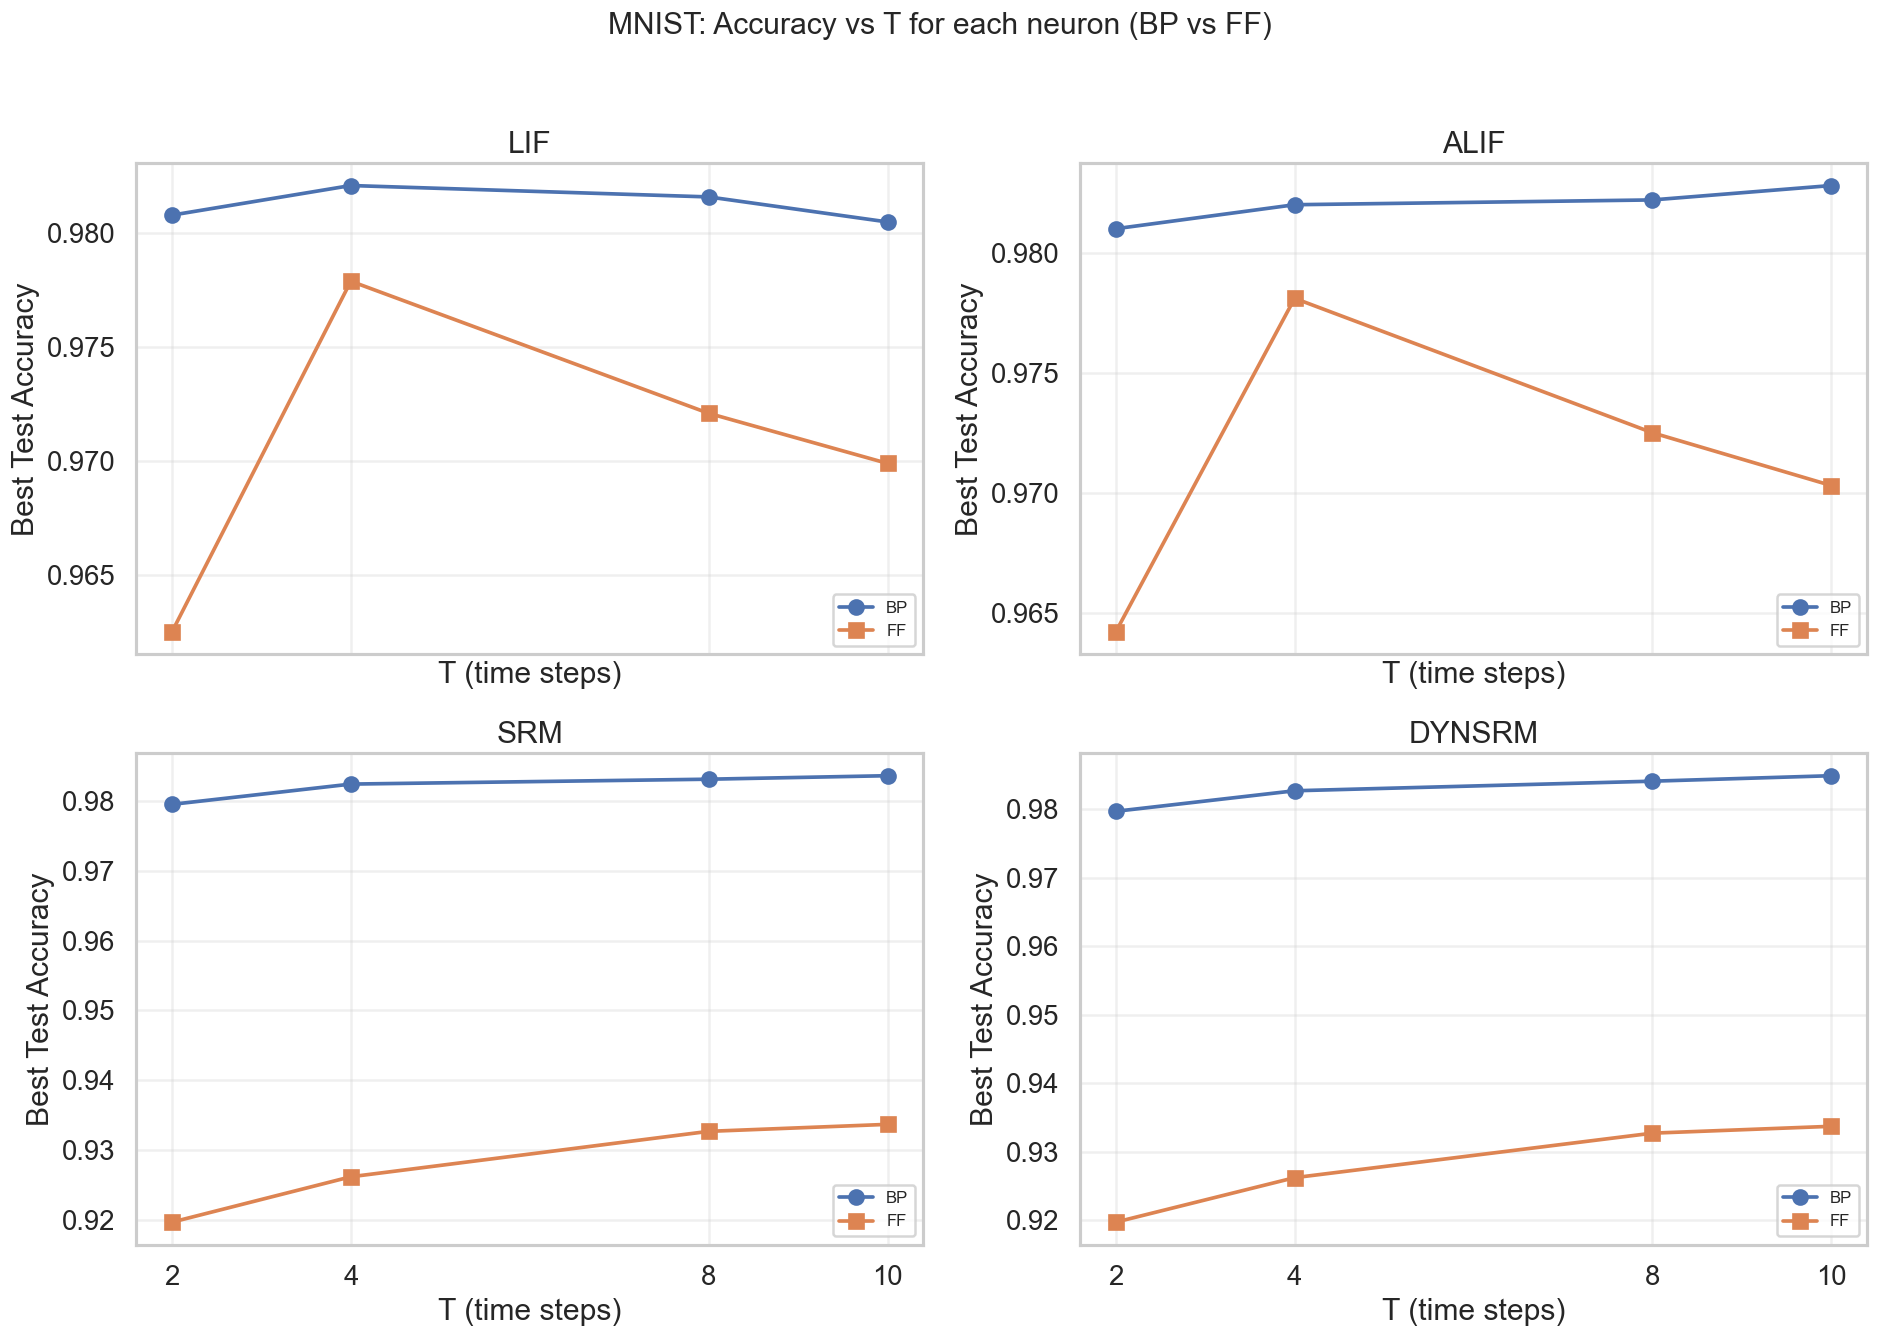


Pivot table (acc):


method,model,T,BP,FF
0,alif,2,0.9810,0.9642
1,alif,4,0.9820,0.9781
2,alif,8,0.9822,0.9725
3,alif,10,0.9828,0.9703
4,dynsrm,2,0.9797,0.9197
5,dynsrm,4,0.9827,0.9262
6,dynsrm,8,0.9841,0.9327
7,dynsrm,10,0.9849,0.9337
8,lif,2,0.9808,0.9625
9,lif,4,0.9821,0.9779


Saved table: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/timestep/plots/bp_ff_accuracy_vs_timestep_table.csv


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True, sharey=False)
axes = axes.ravel()

for i, model in enumerate(NEURONS):
    ax = axes[i]
    sub = result_df[result_df["model"] == model].copy()

    bp = sub[sub["method"] == "BP"].sort_values("T")
    ff = sub[sub["method"] == "FF"].sort_values("T")

    ax.plot(bp["T"], bp["acc"], marker="o", linewidth=2.2, label="BP")
    ax.plot(ff["T"], ff["acc"], marker="s", linewidth=2.2, label="FF")

    ax.set_title(model.upper())
    ax.set_xlabel("T (time steps)")
    ax.set_ylabel("Best Test Accuracy")
    ax.set_xticks(TS)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=10)

fig.suptitle("MNIST: Accuracy vs T for each neuron (BP vs FF)", fontsize=18, y=1.02)
fig.tight_layout()

save_path = FIG_DIR / "bp_ff_accuracy_vs_timestep_per_neuron.png"
fig.savefig(save_path, bbox_inches="tight")
print(f"Saved figure: {save_path}")
plt.show()

# Wide table for quick numeric comparison
table_df = result_df.pivot_table(index=["model", "T"], columns="method", values="acc", aggfunc="max").reset_index()
print("\nPivot table (acc):")
display(table_df)

csv_out = FIG_DIR / "bp_ff_accuracy_vs_timestep_table.csv"
table_df.to_csv(csv_out, index=False)
print(f"Saved table: {csv_out}")


,method,model,T,gpu_alloc_mb,gpu_reserved_mb,cpu_mb,csv_path
0,BP,alif,2,47.286133,72.0,1443.128906,/home/yhxu/spikingjelly/spikingjelly/spikingje...
1,BP,alif,4,66.211914,112.0,1539.000000,/home/yhxu/spikingjelly/spikingjelly/spikingje...
2,BP,alif,8,108.145020,174.0,1452.976562,/home/yhxu/spikingjelly/spikingjelly/spikingje...
3,BP,alif,10,127.020020,204.0,1544.773438,/home/yhxu/spikingjelly/spikingjelly/spikingje...
4,FF,alif,2,307.404785,484.0,1503.175781,/home/yhxu/spikingjelly/spikingjelly/spikingje...
5,FF,alif,4,534.228516,890.0,1592.066406,/home/yhxu/spikingjelly/spikingjelly/spikingje...
6,FF,alif,8,999.991211,1700.0,1494.851562,/home/yhxu/spikingjelly/spikingjelly/spikingje...
7,FF,alif,10,1236.872559,2066.0,1584.199219,/home/yhxu/spikingjelly/spikingjelly/spikingje...
8,BP,dynsrm,2,53.151367,80.0,1438.171875,/home/yhxu/spikingjelly/spikingjelly/spikingje...
9,BP,dynsrm,4,69.401367,114.0,1439.960938,/home/yhxu/spikingjelly/spikingjelly/spikingje...


Saved figure: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/timestep/plots/bp_ff_memory_vs_timestep_per_neuron.png


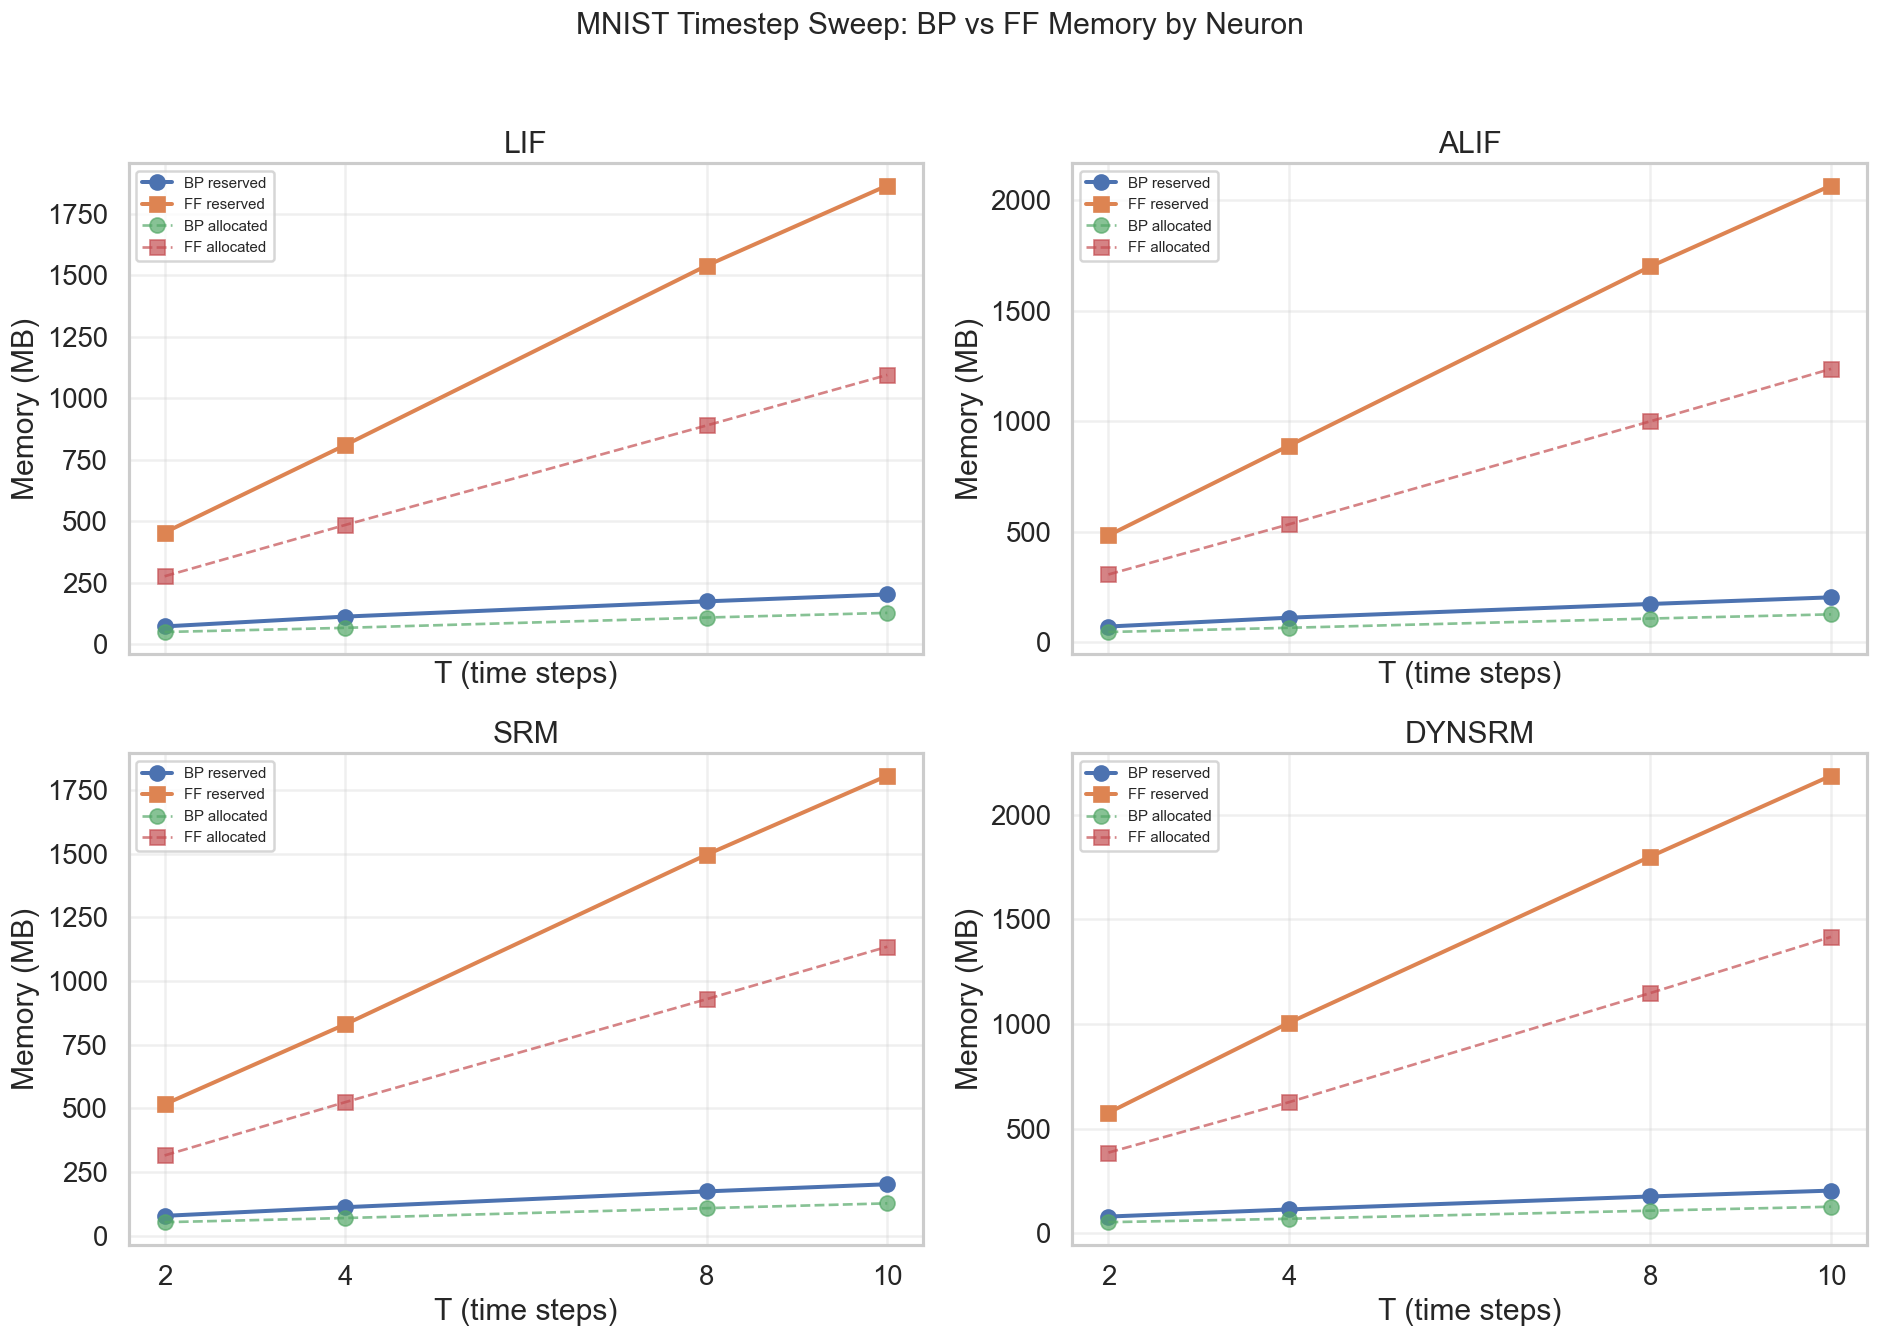

Saved table: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/timestep/plots/bp_ff_memory_vs_timestep_table.csv


In [4]:
# Memory comparison: BP vs FF across T for each neuron

def read_memory_from_csv(csv_path: Path):
    df = pd.read_csv(csv_path)
    if df.empty:
        return {"gpu_alloc_mb": np.nan, "gpu_reserved_mb": np.nan, "cpu_mb": np.nan}

    # Use the row that achieves best_test_acc (or test_acc if best_test_acc is missing).
    score_col = "best_test_acc" if "best_test_acc" in df.columns else ("test_acc" if "test_acc" in df.columns else None)
    if score_col is None:
        row = df.iloc[-1]
    else:
        score = pd.to_numeric(df[score_col], errors="coerce")
        row = df.iloc[int(score.fillna(-np.inf).idxmax())]

    def _num(name):
        if name not in df.columns:
            return np.nan
        return float(pd.to_numeric(pd.Series([row[name]]), errors="coerce").iloc[0])

    train_gpu_alloc = _num("train_gpu_memory_allocated_mb")
    test_gpu_alloc = _num("test_gpu_memory_allocated_mb")
    train_gpu_reserved = _num("train_gpu_memory_reserved_mb")
    test_gpu_reserved = _num("test_gpu_memory_reserved_mb")
    train_cpu = _num("train_cpu_memory_mb")
    test_cpu = _num("test_cpu_memory_mb")

    return {
        "gpu_alloc_mb": np.nanmax([train_gpu_alloc, test_gpu_alloc]),
        "gpu_reserved_mb": np.nanmax([train_gpu_reserved, test_gpu_reserved]),
        "cpu_mb": np.nanmax([train_cpu, test_cpu]),
    }


mem_records = []
for model in NEURONS:
    for t in TS:
        for method in ["BP", "FF"]:
            files = run_csvs(method, model, t)
            if not files:
                mem_records.append({
                    "method": method,
                    "model": model,
                    "T": t,
                    "gpu_alloc_mb": np.nan,
                    "gpu_reserved_mb": np.nan,
                    "cpu_mb": np.nan,
                    "csv_path": "",
                })
                continue

            # Keep selection consistent with accuracy cell: choose file with highest best/test acc.
            best_file = None
            best_acc = -1.0
            for f in files:
                acc = read_best_acc(f)
                if np.isnan(acc):
                    continue
                if acc > best_acc:
                    best_acc = acc
                    best_file = f
            if best_file is None:
                best_file = files[-1]

            mem = read_memory_from_csv(best_file)
            mem_records.append({
                "method": method,
                "model": model,
                "T": t,
                "gpu_alloc_mb": mem["gpu_alloc_mb"],
                "gpu_reserved_mb": mem["gpu_reserved_mb"],
                "cpu_mb": mem["cpu_mb"],
                "csv_path": str(best_file),
            })

mem_df = pd.DataFrame(mem_records).sort_values(["model", "method", "T"]).reset_index(drop=True)
display(mem_df)

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True, sharey=False)
axes = axes.ravel()

for i, model in enumerate(NEURONS):
    ax = axes[i]
    sub = mem_df[mem_df["model"] == model]
    bp = sub[sub["method"] == "BP"].sort_values("T")
    ff = sub[sub["method"] == "FF"].sort_values("T")

    # Compare consumed GPU memory by reserved peak (more representative of footprint).
    ax.plot(bp["T"], bp["gpu_reserved_mb"], marker="o", linewidth=2.4, label="BP reserved")
    ax.plot(ff["T"], ff["gpu_reserved_mb"], marker="s", linewidth=2.4, label="FF reserved")

    # Optional reference: allocated peak with dashed lines.
    ax.plot(bp["T"], bp["gpu_alloc_mb"], marker="o", linestyle="--", linewidth=1.6, alpha=0.7, label="BP allocated")
    ax.plot(ff["T"], ff["gpu_alloc_mb"], marker="s", linestyle="--", linewidth=1.6, alpha=0.7, label="FF allocated")

    ax.set_title(model.upper())
    ax.set_xlabel("T (time steps)")
    ax.set_ylabel("Memory (MB)")
    ax.set_xticks(TS)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc="best")

fig.suptitle("MNIST Timestep Sweep: BP vs FF Memory by Neuron", fontsize=18, y=1.02)
fig.tight_layout()

mem_fig_path = FIG_DIR / "bp_ff_memory_vs_timestep_per_neuron.png"
fig.savefig(mem_fig_path, bbox_inches="tight")
print(f"Saved figure: {mem_fig_path}")
plt.show()

mem_table_path = FIG_DIR / "bp_ff_memory_vs_timestep_table.csv"
mem_df.to_csv(mem_table_path, index=False)
print(f"Saved table: {mem_table_path}")


Saved figure: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/timestep/plots/bp_ff_memory_vs_timestep_per_neuron_robust.png


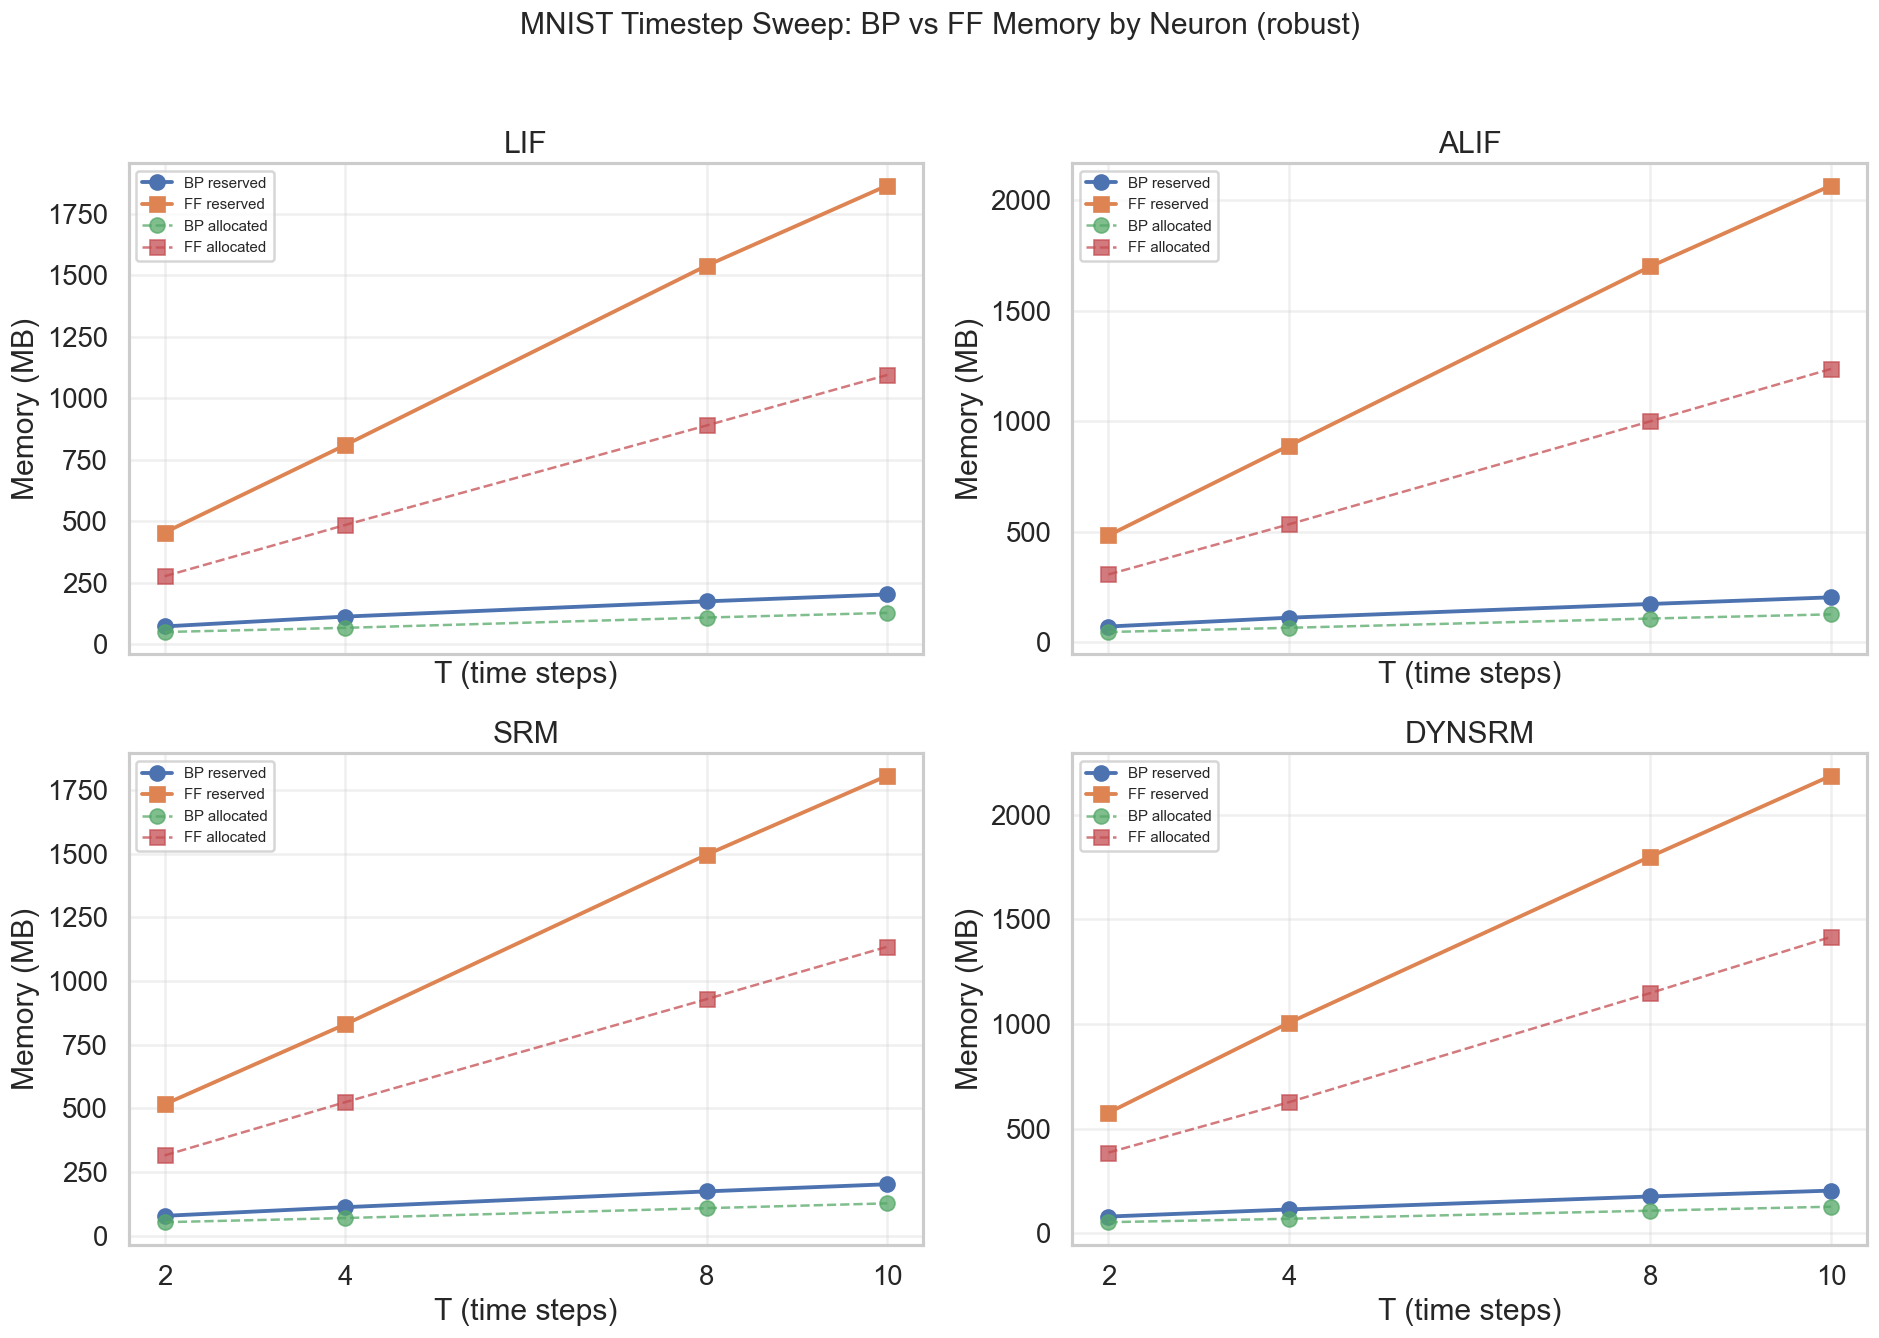

Saved table: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/timestep/plots/bp_ff_memory_vs_timestep_table_robust.csv


,method,model,T,gpu_alloc_mb,gpu_reserved_mb,csv_path
0,BP,alif,2,47.286133,72.0,/home/yhxu/spikingjelly/spikingjelly/spikingje...
1,BP,alif,4,66.211914,112.0,/home/yhxu/spikingjelly/spikingjelly/spikingje...
2,BP,alif,8,108.145020,174.0,/home/yhxu/spikingjelly/spikingjelly/spikingje...
3,BP,alif,10,127.020020,204.0,/home/yhxu/spikingjelly/spikingjelly/spikingje...
4,FF,alif,2,307.404785,484.0,/home/yhxu/spikingjelly/spikingjelly/spikingje...
5,FF,alif,4,534.228516,890.0,/home/yhxu/spikingjelly/spikingjelly/spikingje...
6,FF,alif,8,999.991211,1700.0,/home/yhxu/spikingjelly/spikingjelly/spikingje...
7,FF,alif,10,1236.872559,2066.0,/home/yhxu/spikingjelly/spikingjelly/spikingje...
8,BP,dynsrm,2,53.151367,80.0,/home/yhxu/spikingjelly/spikingjelly/spikingje...
9,BP,dynsrm,4,69.401367,114.0,/home/yhxu/spikingjelly/spikingjelly/spikingje...


In [5]:
# Robust memory plot (no-throw): always generate a figure
import warnings
warnings.filterwarnings("ignore")

# Fallbacks in case previous cells were not run
if "NEURONS" not in globals():
    NEURONS = ["lif", "alif", "srm", "dynsrm"]
if "TS" not in globals():
    TS = [2, 4, 8, 10]
if "BP_ROOT" not in globals():
    BP_ROOT = Path("/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/timestep")
if "FF_ROOT" not in globals():
    FF_ROOT = Path("/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/timestep")
if "FIG_DIR" not in globals():
    FIG_DIR = BP_ROOT / "plots"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if "run_csvs" not in globals():
    import re
    def run_csvs(method: str, model: str, t: int):
        root = BP_ROOT if method == "BP" else FF_ROOT
        subdir = root / model / f"T{t}"
        if not subdir.exists():
            return []
        pat = re.compile(rf"^MNIST_{re.escape(model)}_{method}_v2_\d{{8}}_\d{{6}}\.csv$")
        return sorted([p for p in subdir.glob("*.csv") if pat.match(p.name)], key=lambda p: p.stat().st_mtime)

if "read_best_acc" not in globals():
    def read_best_acc(csv_path: Path) -> float:
        try:
            df = pd.read_csv(csv_path)
            if df.empty:
                return np.nan
            if "best_test_acc" in df.columns:
                return float(pd.to_numeric(df["best_test_acc"], errors="coerce").max())
            if "test_acc" in df.columns:
                return float(pd.to_numeric(df["test_acc"], errors="coerce").max())
        except Exception:
            pass
        return np.nan


def _safe_read_memory(csv_path: Path):
    try:
        df = pd.read_csv(csv_path)
        if df.empty:
            return np.nan, np.nan

        score_col = "best_test_acc" if "best_test_acc" in df.columns else ("test_acc" if "test_acc" in df.columns else None)
        if score_col is None:
            row = df.iloc[-1]
        else:
            score = pd.to_numeric(df[score_col], errors="coerce")
            row = df.iloc[int(score.fillna(-np.inf).idxmax())]

        def _num(col):
            if col not in df.columns:
                return np.nan
            return float(pd.to_numeric(pd.Series([row[col]]), errors="coerce").iloc[0])

        train_alloc = _num("train_gpu_memory_allocated_mb")
        test_alloc = _num("test_gpu_memory_allocated_mb")
        train_res = _num("train_gpu_memory_reserved_mb")
        test_res = _num("test_gpu_memory_reserved_mb")

        alloc = np.nanmax([train_alloc, test_alloc])
        reserved = np.nanmax([train_res, test_res])
        return alloc, reserved
    except Exception:
        return np.nan, np.nan


rows = []
for model in NEURONS:
    for t in TS:
        for method in ["BP", "FF"]:
            try:
                files = run_csvs(method, model, t)
                if not files:
                    rows.append({"method": method, "model": model, "T": t, "gpu_alloc_mb": np.nan, "gpu_reserved_mb": np.nan, "csv_path": ""})
                    continue

                best_file = None
                best_acc = -1.0
                for f in files:
                    acc = read_best_acc(f)
                    if np.isnan(acc):
                        continue
                    if acc > best_acc:
                        best_acc = acc
                        best_file = f
                if best_file is None:
                    best_file = files[-1]

                alloc, reserved = _safe_read_memory(best_file)
                rows.append({"method": method, "model": model, "T": t, "gpu_alloc_mb": alloc, "gpu_reserved_mb": reserved, "csv_path": str(best_file)})
            except Exception:
                rows.append({"method": method, "model": model, "T": t, "gpu_alloc_mb": np.nan, "gpu_reserved_mb": np.nan, "csv_path": ""})

mem_df = pd.DataFrame(rows).sort_values(["model", "method", "T"]).reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True)
axes = axes.ravel()

for i, model in enumerate(NEURONS):
    ax = axes[i]
    sub = mem_df[mem_df["model"] == model]
    bp = sub[sub["method"] == "BP"].sort_values("T")
    ff = sub[sub["method"] == "FF"].sort_values("T")

    drew = False
    if bp["gpu_reserved_mb"].notna().any():
        ax.plot(bp["T"], bp["gpu_reserved_mb"], marker="o", linewidth=2.3, label="BP reserved")
        drew = True
    if ff["gpu_reserved_mb"].notna().any():
        ax.plot(ff["T"], ff["gpu_reserved_mb"], marker="s", linewidth=2.3, label="FF reserved")
        drew = True
    if bp["gpu_alloc_mb"].notna().any():
        ax.plot(bp["T"], bp["gpu_alloc_mb"], marker="o", linestyle="--", linewidth=1.5, alpha=0.75, label="BP allocated")
        drew = True
    if ff["gpu_alloc_mb"].notna().any():
        ax.plot(ff["T"], ff["gpu_alloc_mb"], marker="s", linestyle="--", linewidth=1.5, alpha=0.75, label="FF allocated")
        drew = True

    if not drew:
        ax.text(0.5, 0.5, "No valid memory data", ha="center", va="center", transform=ax.transAxes, fontsize=11)

    ax.set_title(model.upper())
    ax.set_xlabel("T (time steps)")
    ax.set_ylabel("Memory (MB)")
    ax.set_xticks(TS)
    ax.grid(True, alpha=0.3)
    if drew:
        ax.legend(fontsize=9, loc="best")

fig.suptitle("MNIST Timestep Sweep: BP vs FF Memory by Neuron (robust)", fontsize=18, y=1.02)
fig.tight_layout()

out_png = FIG_DIR / "bp_ff_memory_vs_timestep_per_neuron_robust.png"
fig.savefig(out_png, bbox_inches="tight")
print(f"Saved figure: {out_png}")
plt.show()

out_csv = FIG_DIR / "bp_ff_memory_vs_timestep_table_robust.csv"
mem_df.to_csv(out_csv, index=False)
print(f"Saved table: {out_csv}")
display(mem_df)


In [1]:
# Fairer memory comparison under different batch sizes (BP=128, FF=4096)
# 1) memory per sample
# 2) memory scaled to an equivalent target batch size (default 128)

if "mem_df" not in globals() or mem_df.empty:
    raise RuntimeError("Please run the memory extraction cell first to create mem_df.")

BATCH_SIZE_BY_METHOD = {"BP": 128.0, "FF": 4096.0}
# FF local learning usually processes positive+negative branches together,
# so use 2x effective samples for per-sample normalization.
EFFECTIVE_SAMPLE_FACTOR = {"BP": 1.0, "FF": 2.0}
TARGET_BATCH = 128.0

fair_df = mem_df.copy()
fair_df["batch_size"] = fair_df["method"].map(BATCH_SIZE_BY_METHOD)
fair_df["effective_sample_factor"] = fair_df["method"].map(EFFECTIVE_SAMPLE_FACTOR)
fair_df["effective_batch_size"] = fair_df["batch_size"] * fair_df["effective_sample_factor"]

# Normalize by effective sample count.
fair_df["gpu_reserved_mb_per_sample"] = fair_df["gpu_reserved_mb"] / fair_df["effective_batch_size"]
fair_df["gpu_alloc_mb_per_sample"] = fair_df["gpu_alloc_mb"] / fair_df["effective_batch_size"]

# Scale to an equivalent target batch (approximate linear scaling assumption).
scale = TARGET_BATCH / fair_df["effective_batch_size"]
fair_df["gpu_reserved_mb_eq_target_batch"] = fair_df["gpu_reserved_mb"] * scale
fair_df["gpu_alloc_mb_eq_target_batch"] = fair_df["gpu_alloc_mb"] * scale

display(fair_df[["method", "model", "T", "batch_size", "effective_sample_factor", "effective_batch_size", "gpu_reserved_mb", "gpu_reserved_mb_per_sample", "gpu_reserved_mb_eq_target_batch"]])

from IPython.display import display, Image

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True)
axes = axes.ravel()

bp_color = "#1f77b4"  # blue
ff_color = "#d62728"  # red

for i, model in enumerate(NEURONS):
    ax_l = axes[i]
    ax_r = ax_l.twinx()

    sub = fair_df[fair_df["model"] == model]
    bp = sub[sub["method"] == "BP"].sort_values("T")
    ff = sub[sub["method"] == "FF"].sort_values("T")

    x = np.arange(len(TS))
    width = 0.34

    # Right axis: equivalent memory at target batch -> grouped bars (more obvious)
    bp_eq = bp["gpu_reserved_mb_eq_target_batch"].reindex(bp.index).values
    ff_eq = ff["gpu_reserved_mb_eq_target_batch"].reindex(ff.index).values
    b1 = ax_r.bar(x - width / 2, bp_eq, width=width, color=bp_color, alpha=0.35,
                  edgecolor=bp_color, linewidth=1.2, label=f"BP @bs={int(TARGET_BATCH)}")
    b2 = ax_r.bar(x + width / 2, ff_eq, width=width, color=ff_color, alpha=0.35,
                  edgecolor=ff_color, linewidth=1.2, label=f"FF @bs={int(TARGET_BATCH)}")

    # Left axis: per-sample memory -> lines
    l1, = ax_l.plot(x, bp["gpu_reserved_mb_per_sample"].values, marker="o", linewidth=2.6, color=bp_color,
                    label="BP / effective-sample")
    l2, = ax_l.plot(x, ff["gpu_reserved_mb_per_sample"].values, marker="s", linewidth=2.6, color=ff_color,
                    label="FF / effective-sample")

    # Tighten ranges on both axes for better visual comparison
    left_vals = np.concatenate([
        bp["gpu_reserved_mb_per_sample"].dropna().values,
        ff["gpu_reserved_mb_per_sample"].dropna().values,
    ])
    if left_vals.size > 0:
        lmin, lmax = np.nanmin(left_vals), np.nanmax(left_vals)
        pad = max((lmax - lmin) * 0.16, 1e-6)
        ax_l.set_ylim(max(0.0, lmin - pad), lmax + pad)

    right_vals = np.concatenate([
        bp["gpu_reserved_mb_eq_target_batch"].dropna().values,
        ff["gpu_reserved_mb_eq_target_batch"].dropna().values,
    ])
    if right_vals.size > 0:
        rmin, rmax = np.nanmin(right_vals), np.nanmax(right_vals)
        pad = max((rmax - rmin) * 0.16, 1e-6)
        ax_r.set_ylim(max(0.0, rmin - pad), rmax + pad)

    ax_l.set_title(model.upper())
    ax_l.set_xlabel("T (time steps)")
    ax_l.set_xticks(x)
    ax_l.set_xticklabels(TS)
    ax_l.set_ylabel("Per-effective-sample Memory (MB)", color=bp_color)
    ax_r.set_ylabel(f"Equivalent Memory @effective-bs={int(TARGET_BATCH)} (MB)", color=ff_color)
    ax_l.tick_params(axis="y", colors=bp_color)
    ax_r.tick_params(axis="y", colors=ff_color)
    ax_l.grid(True, alpha=0.28)

    handles = [l1, l2, b1, b2]
    labels = [h.get_label() for h in handles]
    ax_l.legend(handles, labels, fontsize=8, loc="best")

fig.suptitle("MNIST: Fairer Memory Comparison (lines + bars, one figure)", fontsize=18, y=1.02)
fig.tight_layout()

fair_fig_path = FIG_DIR / "bp_ff_memory_vs_timestep_fair_batch_normalized.png"
fig.savefig(fair_fig_path, bbox_inches="tight")
print(f"Saved figure: {fair_fig_path}")
plt.show()

# Explicit inline display in notebook
try:
    display(Image(filename=str(fair_fig_path)))
except Exception:
    pass

fair_csv_path = FIG_DIR / "bp_ff_memory_vs_timestep_fair_batch_normalized_table.csv"
fair_df.to_csv(fair_csv_path, index=False)
print(f"Saved table: {fair_csv_path}")


RuntimeError: Please run the memory extraction cell first to create mem_df.

,method,model,T,train_speed_samples_per_s,train_time_sec,epoch_time_sec,train_latency_ms_per_sample,time_for_10k_samples_sec,csv_path
0,BP,alif,2,NaN,15.428679,18.363923,0.257282,NaN,/home/yhxu/spikingjelly/spikingjelly/spikingje...
1,BP,alif,4,NaN,16.154788,18.533039,0.269390,NaN,/home/yhxu/spikingjelly/spikingjelly/spikingje...
2,BP,alif,8,NaN,15.296979,17.942818,0.255086,NaN,/home/yhxu/spikingjelly/spikingjelly/spikingje...
3,BP,alif,10,NaN,15.656286,18.011428,0.261077,NaN,/home/yhxu/spikingjelly/spikingjelly/spikingje...
4,FF,alif,2,NaN,14.551612,32.600939,0.253760,NaN,/home/yhxu/spikingjelly/spikingjelly/spikingje...
5,FF,alif,4,NaN,14.477287,32.663087,0.252464,NaN,/home/yhxu/spikingjelly/spikingjelly/spikingje...
6,FF,alif,8,NaN,14.316352,32.620572,0.249657,NaN,/home/yhxu/spikingjelly/spikingjelly/spikingje...
7,FF,alif,10,NaN,13.064006,30.518258,0.227818,NaN,/home/yhxu/spikingjelly/spikingjelly/spikingje...
8,BP,dynsrm,2,NaN,15.783608,18.405373,0.263201,NaN,/home/yhxu/spikingjelly/spikingjelly/spikingje...
9,BP,dynsrm,4,NaN,15.084025,18.002442,0.251535,NaN,/home/yhxu/spikingjelly/spikingjelly/spikingje...


Saved figure: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/timestep/plots/bp_ff_training_time_vs_timestep_fair.png


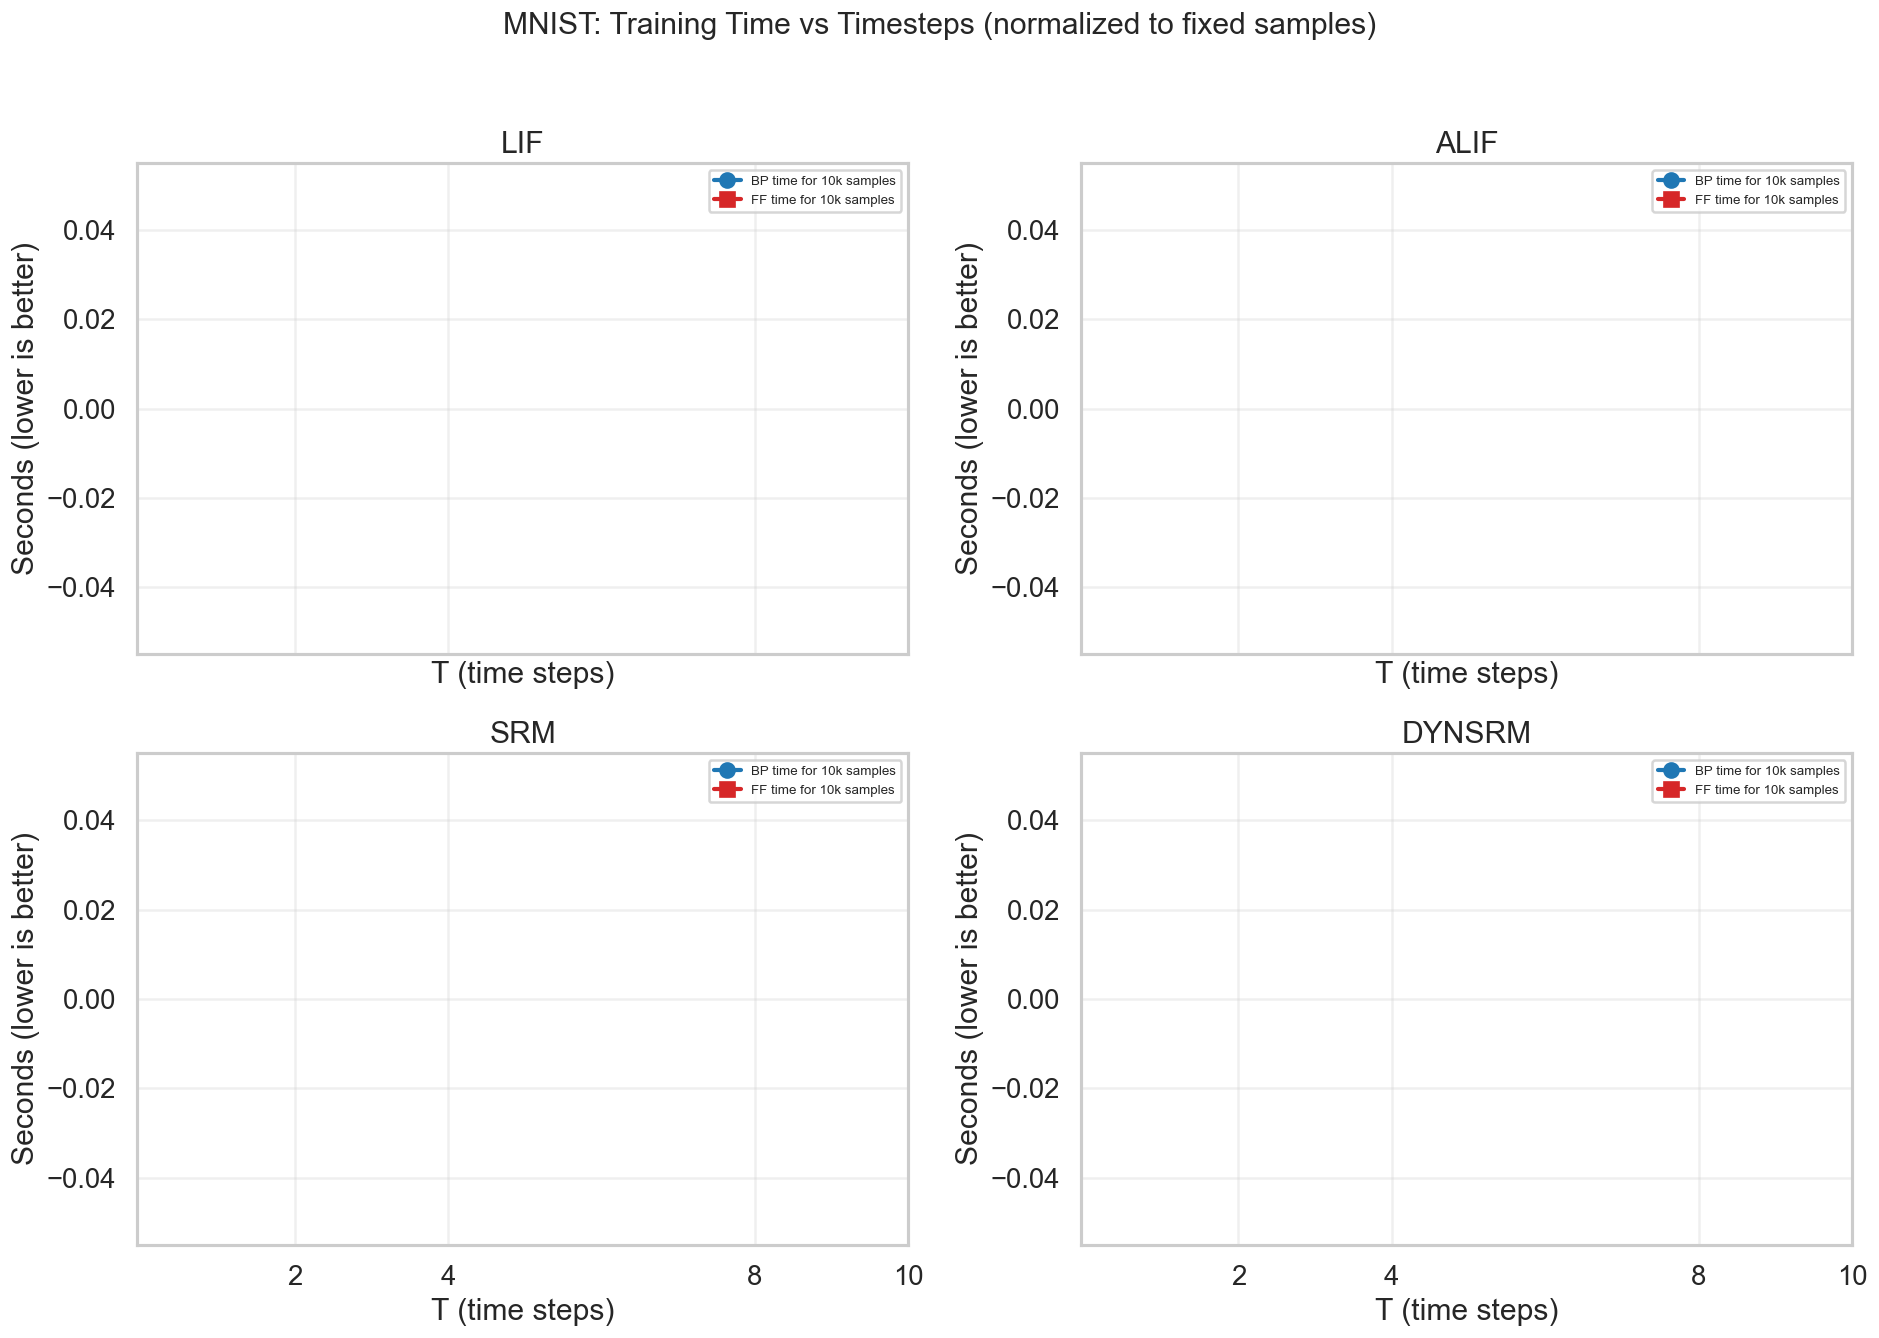

In [9]:
# Training Time vs Timesteps (fair standard)
# Standard used here: compare time for a fixed number of samples, so BP/FF with different batch sizes are comparable.

STD_SAMPLES = 10000.0

if "NEURONS" not in globals():
    NEURONS = ["lif", "alif", "srm", "dynsrm"]
if "TS" not in globals():
    TS = [2, 4, 8, 10]
if "FIG_DIR" not in globals():
    FIG_DIR = Path("/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/timestep/plots")
FIG_DIR.mkdir(parents=True, exist_ok=True)


def _safe_num(v):
    try:
        return float(pd.to_numeric(pd.Series([v]), errors="coerce").iloc[0])
    except Exception:
        return np.nan


def read_timing_from_csv(csv_path: Path):
    df = pd.read_csv(csv_path)
    if df.empty:
        return {"train_speed_samples_per_s": np.nan, "train_time_sec": np.nan, "epoch_time_sec": np.nan, "train_latency_ms_per_sample": np.nan}

    score_col = "best_test_acc" if "best_test_acc" in df.columns else ("test_acc" if "test_acc" in df.columns else None)
    if score_col is None:
        row = df.iloc[-1]
    else:
        score = pd.to_numeric(df[score_col], errors="coerce")
        row = df.iloc[int(score.fillna(-np.inf).idxmax())]

    speed = _safe_num(row.get("train_speed_samples_per_s", np.nan))
    train_time = _safe_num(row.get("train_time_sec", np.nan))
    epoch_time = _safe_num(row.get("epoch_time_sec", np.nan))
    latency = _safe_num(row.get("train_latency_ms_per_sample", np.nan))

    if np.isnan(latency) and not np.isnan(speed) and speed > 0:
        latency = 1000.0 / speed

    return {
        "train_speed_samples_per_s": speed,
        "train_time_sec": train_time,
        "epoch_time_sec": epoch_time,
        "train_latency_ms_per_sample": latency,
    }


timing_records = []
for model in NEURONS:
    for t in TS:
        for method in ["BP", "FF"]:
            files = run_csvs(method, model, t) if "run_csvs" in globals() else []
            if not files:
                timing_records.append({"method": method, "model": model, "T": t, "train_speed_samples_per_s": np.nan,
                                       "train_time_sec": np.nan, "epoch_time_sec": np.nan, "train_latency_ms_per_sample": np.nan,
                                       "time_for_10k_samples_sec": np.nan, "csv_path": ""})
                continue

            best_file, best_acc = None, -1.0
            for f in files:
                acc = read_best_acc(f) if "read_best_acc" in globals() else np.nan
                if np.isnan(acc):
                    continue
                if acc > best_acc:
                    best_acc = acc
                    best_file = f
            if best_file is None:
                best_file = files[-1]

            tm = read_timing_from_csv(best_file)
            speed = tm["train_speed_samples_per_s"]
            std_time = (STD_SAMPLES / speed) if (not np.isnan(speed) and speed > 0) else np.nan
            timing_records.append({
                "method": method,
                "model": model,
                "T": t,
                "train_speed_samples_per_s": speed,
                "train_time_sec": tm["train_time_sec"],
                "epoch_time_sec": tm["epoch_time_sec"],
                "train_latency_ms_per_sample": tm["train_latency_ms_per_sample"],
                "time_for_10k_samples_sec": std_time,
                "csv_path": str(best_file),
            })

timing_df = pd.DataFrame(timing_records).sort_values(["model", "method", "T"]).reset_index(drop=True)
display(timing_df)

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True)
axes = axes.ravel()
bp_color, ff_color = "#1f77b4", "#d62728"

for i, model in enumerate(NEURONS):
    ax = axes[i]
    sub = timing_df[timing_df["model"] == model]
    bp = sub[sub["method"] == "BP"].sort_values("T")
    ff = sub[sub["method"] == "FF"].sort_values("T")

    # Primary fair metric: time for fixed workload (10k samples)
    ax.plot(bp["T"], bp["time_for_10k_samples_sec"], marker="o", linewidth=2.5, color=bp_color, label="BP time for 10k samples")
    ax.plot(ff["T"], ff["time_for_10k_samples_sec"], marker="s", linewidth=2.5, color=ff_color, label="FF time for 10k samples")

    ax.set_title(model.upper())
    ax.set_xlabel("T (time steps)")
    ax.set_ylabel("Seconds (lower is better)")
    ax.set_xticks(TS)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="best")

fig.suptitle("MNIST: Training Time vs Timesteps (normalized to fixed samples)", fontsize=18, y=1.02)
fig.tight_layout()

time_fig_path = FIG_DIR / "bp_ff_training_time_vs_timestep_fair.png"
fig.savefig(time_fig_path, bbox_inches="tight")
print(f"Saved figure: {time_fig_path}")
plt.show()


Saved figure: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/timestep/plots/bp_ff_throughput_vs_timestep_fair.png


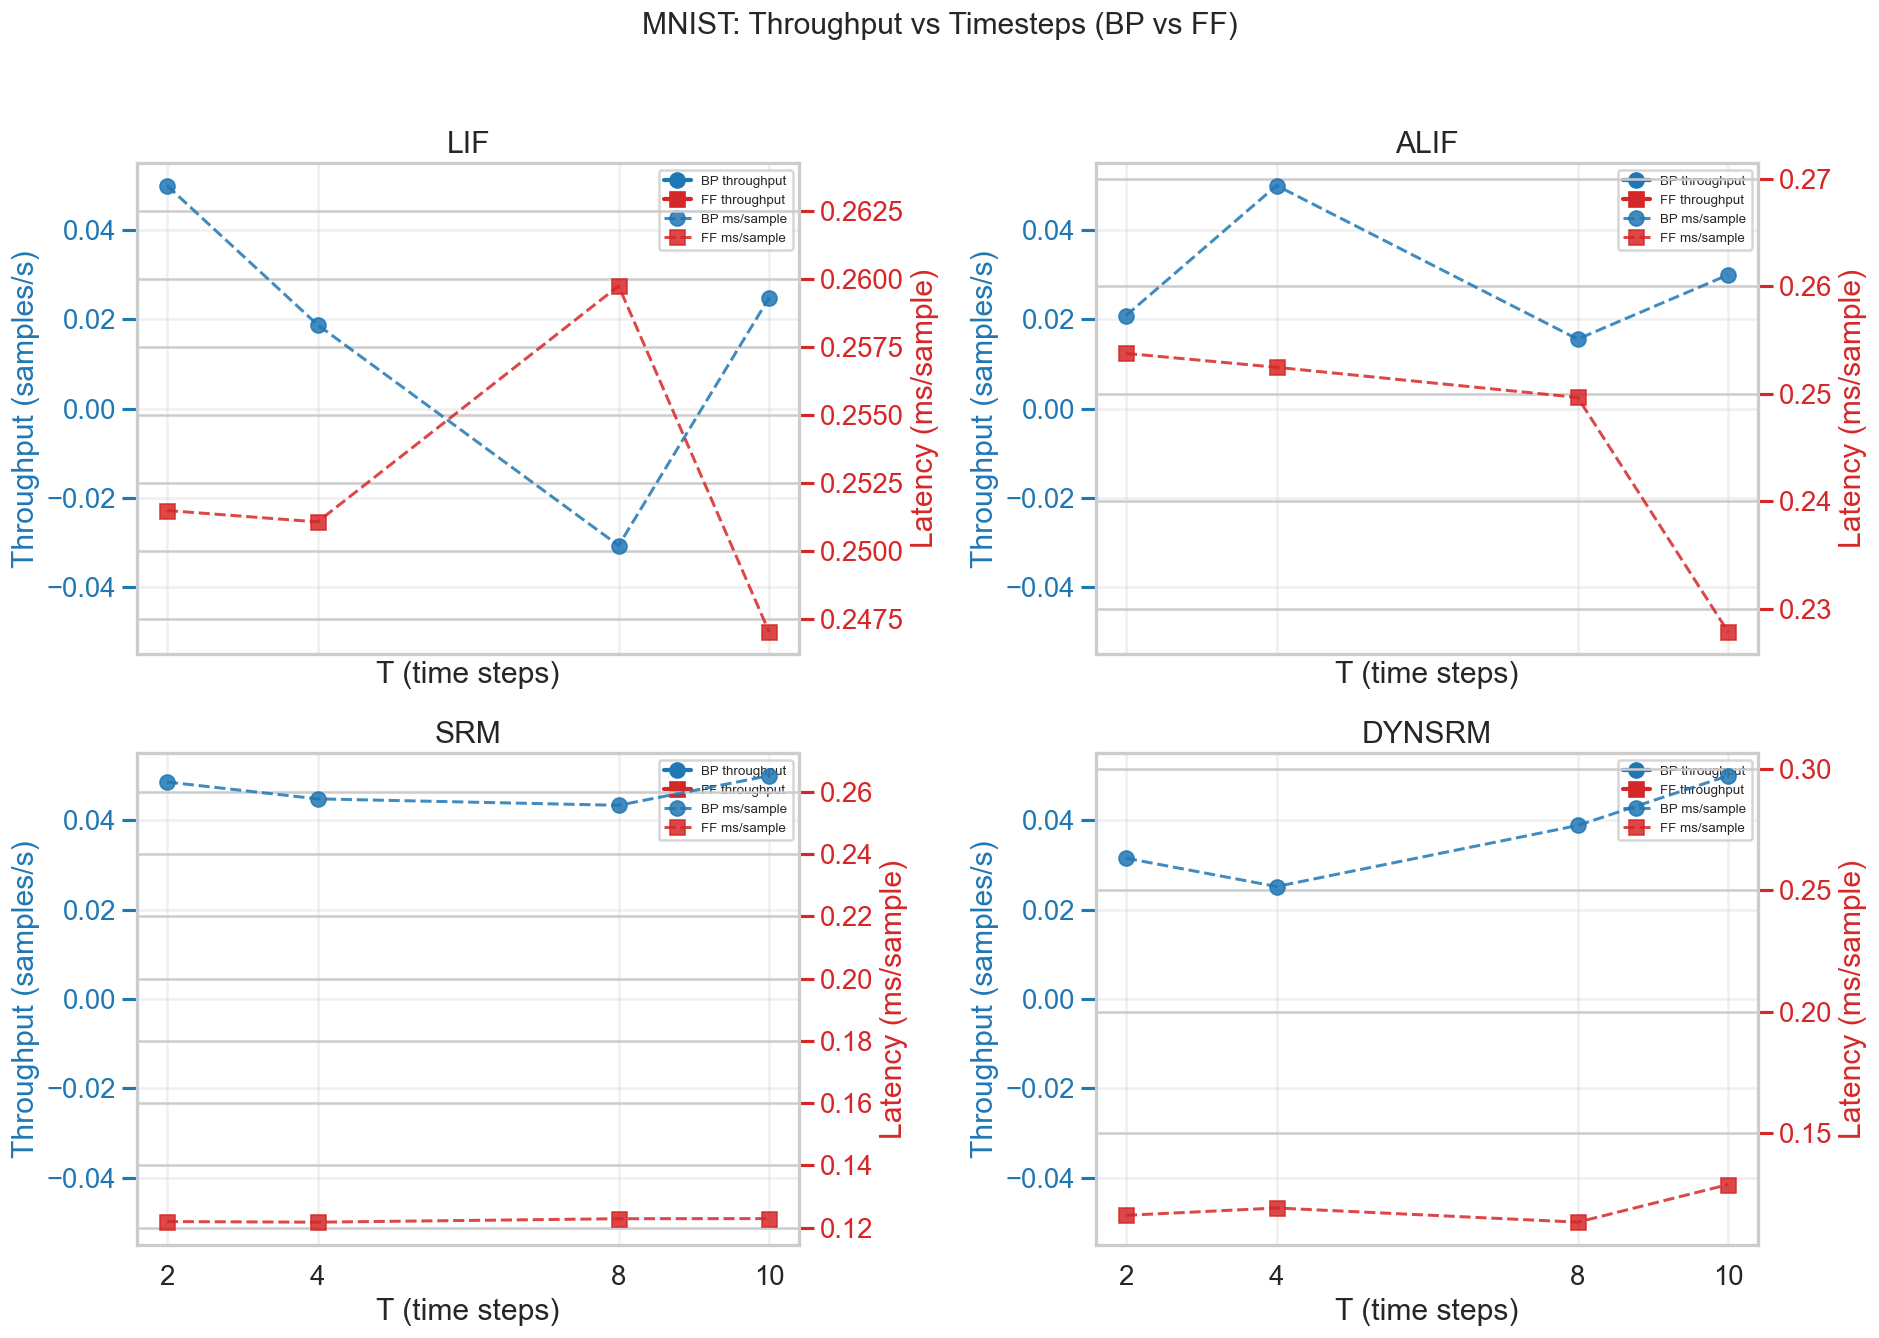

Saved table: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/timestep/plots/bp_ff_training_time_throughput_vs_timestep_table.csv


In [10]:
# Throughput vs Timesteps (same selected runs / same standard)
# Primary metric: samples/sec. Secondary metric: ms/sample.

if "timing_df" not in globals() or timing_df.empty:
    raise RuntimeError("Please run the previous timing cell first to create timing_df.")

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True)
axes = axes.ravel()
bp_color, ff_color = "#1f77b4", "#d62728"

for i, model in enumerate(NEURONS):
    ax_l = axes[i]
    ax_r = ax_l.twinx()

    sub = timing_df[timing_df["model"] == model]
    bp = sub[sub["method"] == "BP"].sort_values("T")
    ff = sub[sub["method"] == "FF"].sort_values("T")

    # Left axis: throughput samples/s (higher is better)
    l1, = ax_l.plot(bp["T"], bp["train_speed_samples_per_s"], marker="o", linewidth=2.5, color=bp_color, label="BP throughput")
    l2, = ax_l.plot(ff["T"], ff["train_speed_samples_per_s"], marker="s", linewidth=2.5, color=ff_color, label="FF throughput")

    # Right axis: latency ms/sample (lower is better)
    l3, = ax_r.plot(bp["T"], bp["train_latency_ms_per_sample"], marker="o", linestyle="--", linewidth=1.8, alpha=0.85,
                    color=bp_color, label="BP ms/sample")
    l4, = ax_r.plot(ff["T"], ff["train_latency_ms_per_sample"], marker="s", linestyle="--", linewidth=1.8, alpha=0.85,
                    color=ff_color, label="FF ms/sample")

    ax_l.set_title(model.upper())
    ax_l.set_xlabel("T (time steps)")
    ax_l.set_ylabel("Throughput (samples/s)", color=bp_color)
    ax_r.set_ylabel("Latency (ms/sample)", color=ff_color)
    ax_l.tick_params(axis="y", colors=bp_color)
    ax_r.tick_params(axis="y", colors=ff_color)
    ax_l.set_xticks(TS)
    ax_l.grid(True, alpha=0.3)

    handles = [l1, l2, l3, l4]
    labels = [h.get_label() for h in handles]
    ax_l.legend(handles, labels, fontsize=8, loc="best")

fig.suptitle("MNIST: Throughput vs Timesteps (BP vs FF)", fontsize=18, y=1.02)
fig.tight_layout()

throughput_fig_path = FIG_DIR / "bp_ff_throughput_vs_timestep_fair.png"
fig.savefig(throughput_fig_path, bbox_inches="tight")
print(f"Saved figure: {throughput_fig_path}")
plt.show()

timing_csv_out = FIG_DIR / "bp_ff_training_time_throughput_vs_timestep_table.csv"
timing_df.to_csv(timing_csv_out, index=False)
print(f"Saved table: {timing_csv_out}")


Event/Dense ratio rows: 32


,method,model,T,event_dense_ratio,ratio_col,csv_path
0,BP,alif,2,0.191631,test_event_to_dense_ratio,/home/yhxu/spikingjelly/spikingjelly/spikingje...
1,BP,alif,4,0.191989,test_event_to_dense_ratio,/home/yhxu/spikingjelly/spikingjelly/spikingje...
2,BP,alif,8,0.192356,test_event_to_dense_ratio,/home/yhxu/spikingjelly/spikingjelly/spikingje...
3,BP,alif,10,0.192540,test_event_to_dense_ratio,/home/yhxu/spikingjelly/spikingjelly/spikingje...
4,FF,alif,2,0.165964,test_event_to_dense_ratio,/home/yhxu/spikingjelly/spikingjelly/spikingje...
5,FF,alif,4,0.128164,test_event_to_dense_ratio,/home/yhxu/spikingjelly/spikingjelly/spikingje...
6,FF,alif,8,0.120462,test_event_to_dense_ratio,/home/yhxu/spikingjelly/spikingjelly/spikingje...
7,FF,alif,10,0.119599,test_event_to_dense_ratio,/home/yhxu/spikingjelly/spikingjelly/spikingje...
8,BP,dynsrm,2,0.192150,test_event_to_dense_ratio,/home/yhxu/spikingjelly/spikingjelly/spikingje...
9,BP,dynsrm,4,0.192336,test_event_to_dense_ratio,/home/yhxu/spikingjelly/spikingjelly/spikingje...


Saved figure: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/timestep/plots/bp_ff_event_dense_ratio_vs_timestep.png


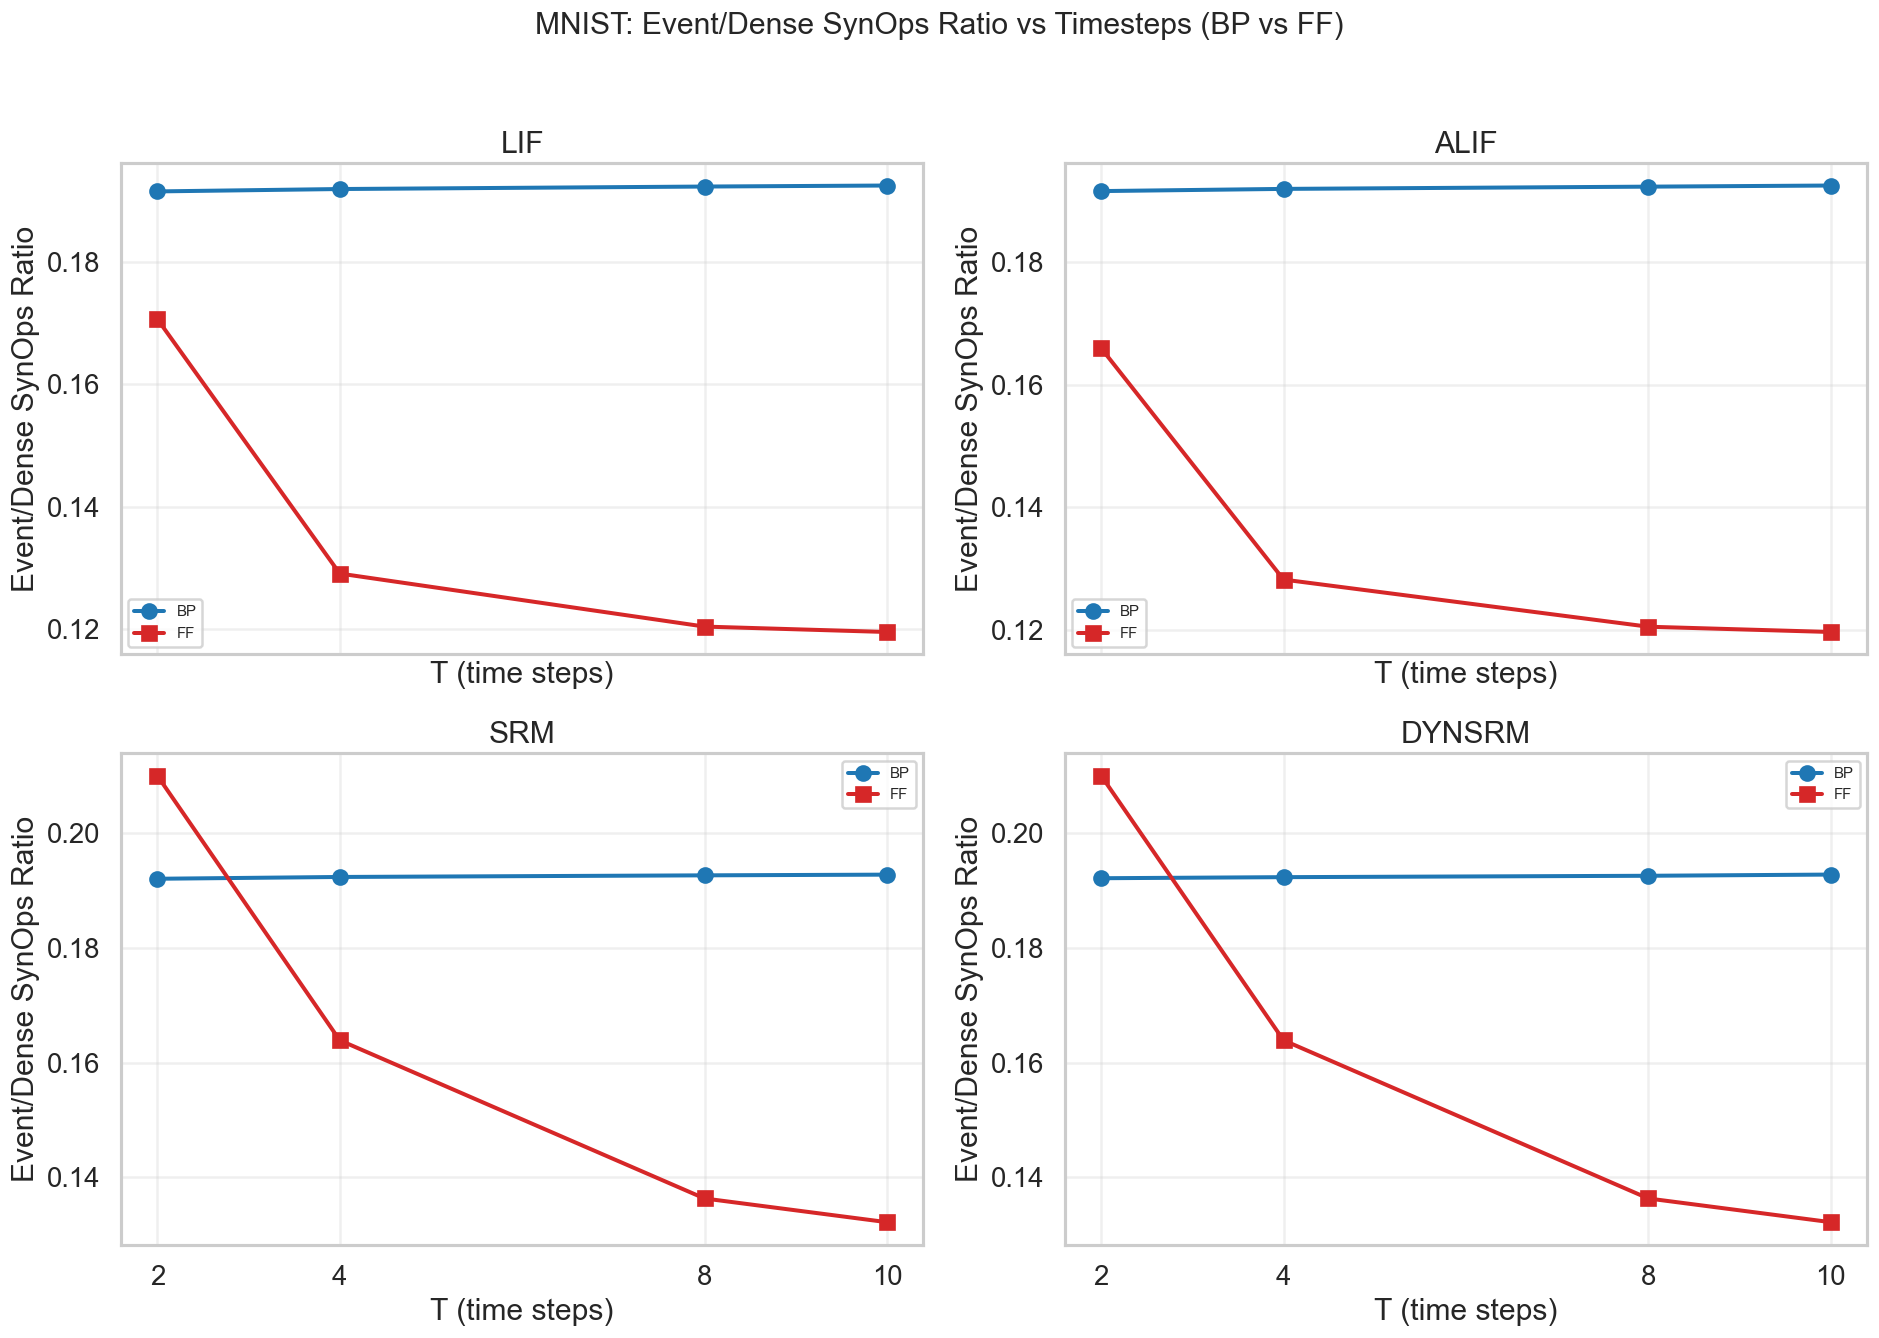

Saved table: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/timestep/plots/bp_ff_event_dense_ratio_vs_timestep_table.csv


In [11]:
# Event/Dense SynOps ratio vs Timesteps (BP vs FF)
# Mimic the style of scientific comparison: method-colored curves + clear annotations/table.

ratio_col_candidates = [
    "test_event_to_dense_ratio",      # MNIST BP/FF v2 common
    "final_test_event_ratio",         # fallback naming
    "mean_event_to_dense_ratio",      # some scripts use mean_* naming
]


def read_ratio_from_csv(csv_path: Path):
    df = pd.read_csv(csv_path)
    if df.empty:
        return np.nan, None

    score_col = "best_test_acc" if "best_test_acc" in df.columns else ("test_acc" if "test_acc" in df.columns else None)
    if score_col is None:
        row = df.iloc[-1]
    else:
        score = pd.to_numeric(df[score_col], errors="coerce")
        row = df.iloc[int(score.fillna(-np.inf).idxmax())]

    for c in ratio_col_candidates:
        if c in df.columns:
            v = pd.to_numeric(pd.Series([row[c]]), errors="coerce").iloc[0]
            return float(v) if pd.notna(v) else np.nan, c

    return np.nan, None


ratio_records = []
for model in NEURONS:
    for t in TS:
        for method in ["BP", "FF"]:
            files = run_csvs(method, model, t) if "run_csvs" in globals() else []
            if not files:
                ratio_records.append({
                    "method": method,
                    "model": model,
                    "T": t,
                    "event_dense_ratio": np.nan,
                    "ratio_col": "",
                    "csv_path": "",
                })
                continue

            best_file = None
            best_acc = -1.0
            for f in files:
                acc = read_best_acc(f) if "read_best_acc" in globals() else np.nan
                if np.isnan(acc):
                    continue
                if acc > best_acc:
                    best_acc = acc
                    best_file = f
            if best_file is None:
                best_file = files[-1]

            ratio, used_col = read_ratio_from_csv(best_file)
            ratio_records.append({
                "method": method,
                "model": model,
                "T": t,
                "event_dense_ratio": ratio,
                "ratio_col": "" if used_col is None else used_col,
                "csv_path": str(best_file),
            })

ratio_df = pd.DataFrame(ratio_records).sort_values(["model", "method", "T"]).reset_index(drop=True)
print("Event/Dense ratio rows:", len(ratio_df))
display(ratio_df)

# Plot by neuron (2x2), BP vs FF across T
fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True, sharey=False)
axes = axes.ravel()
color_map = {"BP": "#1f77b4", "FF": "#d62728"}
marker_map = {"BP": "o", "FF": "s"}

for i, model in enumerate(NEURONS):
    ax = axes[i]
    sub = ratio_df[ratio_df["model"] == model]

    for method in ["BP", "FF"]:
        d = sub[sub["method"] == method].sort_values("T")
        ax.plot(
            d["T"],
            d["event_dense_ratio"],
            marker=marker_map[method],
            linewidth=2.4,
            color=color_map[method],
            label=method,
        )

    ax.set_title(model.upper())
    ax.set_xlabel("T (time steps)")
    ax.set_ylabel("Event/Dense SynOps Ratio")
    ax.set_xticks(TS)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=9)

fig.suptitle("MNIST: Event/Dense SynOps Ratio vs Timesteps (BP vs FF)", fontsize=18, y=1.02)
fig.tight_layout()

ratio_fig_path = FIG_DIR / "bp_ff_event_dense_ratio_vs_timestep.png"
fig.savefig(ratio_fig_path, bbox_inches="tight")
print(f"Saved figure: {ratio_fig_path}")
plt.show()

ratio_table_path = FIG_DIR / "bp_ff_event_dense_ratio_vs_timestep_table.csv"
ratio_df.to_csv(ratio_table_path, index=False)
print(f"Saved table: {ratio_table_path}")
